# Lab9: Radioactive Decay - Half-Life, Randomness, and Carbon Dating

---

## **Overview**

Radioactive decay is both **predictable** (it follows an exponential law) and **random** (individual decays are probabilistic). In this lab you will connect these two ideas using:

- **Part A:** A published-style decay dataset (Ba-137m–like) to measure a half-life.
- **Part B:** A hands-on dice activity to model the randomness of decay and the meaning of half-life.
- **Part C:** A Monte Carlo model of **radiocarbon dating** to explore uncertainty, background, contamination, and dating limits.

---

## **Learning Objectives**

By the end of this lab, you will be able to:

1. Fit count-vs-time data to an exponential decay model and extract a half-life.
2. Explain half-life as a consequence of a constant decay probability per unit time.
3. Describe and quantify counting statistics and why uncertainties scale like \(\sqrt{N}\).
4. Use Monte Carlo simulation to model radiocarbon dating and estimate age uncertainty.
5. Explain how contamination and background affect carbon dating results.

---

## **Background Theory**

### 1) Exponential Decay

If a nucleus has a constant probability per unit time to decay, then the number of undecayed nuclei follows:

$$
N(t) = N_0 e^{-\lambda t}
$$

The half-life $t_{1/2}$ satisfies $N(t_{1/2}) = N_0/2$, giving:

$$
t_{1/2} = \frac{\ln 2}{\lambda}
$$

### 2) From Nuclei to Measured Counts + Background

In a counting experiment, we measure counts per bin:

$$
C(t) = C_0 e^{-\lambda t} + B
$$

- $C_0$: initial signal scale (counts/bin)
- $B$: background counts/bin (assumed constant over the run)

### 3) Counting Statistics (Poisson)

Radioactive decay is a **stochastic (random) process**. Each nucleus has a fixed probability per unit time to decay, but we cannot predict **which specific nucleus will decay or exactly when it will decay**. Because of this randomness, the number of decay events detected during a fixed time interval fluctuates from one measurement to the next.

Suppose that, on average, we expect $\mu$ decay events during a particular counting interval. The actual number of events we measure in that interval is a random variable. For radioactive decay and other counting processes involving independent events, the probability of observing exactly $k$ counts is described by the **Poisson distribution**:

$$
P(k) = \frac{\mu^k e^{-\mu}}{k!}
$$

The variables in this equation have different meanings:

| Symbol | Meaning | Type |
|------|------|------|
| $\mu$ | Expected (average) number of counts in a time interval | Model parameter |
| $k$ | Possible number of counts that *could* be measured | Random variable |
| $C$ | The **actual number of counts measured in the experiment** | Observed data |

In other words:

- $\mu$ is the **expected mean count rate** predicted by the physical model.
- $k$ represents a **possible outcome** of the counting process.
- $C$ is the **specific value measured in your experiment**.

For example, if the expected number of counts is $\mu = 100$, the detector will not measure exactly 100 every time. Instead, repeated measurements might produce values such as

$$
k = 94,\; 101,\; 98,\; 105,\; 96,\dots
$$

Each of these outcomes occurs with a probability given by the Poisson distribution.

A key property of the Poisson distribution is that its standard deviation is

$$
\sigma = \sqrt{\mu}.
$$

In practice, we usually do not know the true mean $\mu$, so we estimate the uncertainty using the measured counts $C$:

$$
\sigma_C \approx \sqrt{C}.
$$

This means that even if the underlying decay law is perfectly exponential, the measured counts will fluctuate around the expected value. These fluctuations are **not experimental mistakes**—they are a natural consequence of the random nature of radioactive decay.

The relative size of these fluctuations decreases as the count rate increases:

$$
\frac{\sigma_C}{C} \approx \frac{1}{\sqrt{C}}.
$$

Therefore:

- When the count rate is **large**, the data appear smooth and the exponential trend is clear.
- When the count rate becomes **small**, the fluctuations become more noticeable.

This becomes especially important at **late times** in a decay experiment, when the signal becomes comparable to the **background count rate**. In that regime, the random fluctuations can significantly affect the analysis of the decay curve.

### 4) Radiocarbon Dating Model

Radiocarbon dating uses the decay of ${}^{14}\mathrm{C}$, with half-life:

$$
t_{1/2,14} \approx 5730~\text{years}
$$

Decay constant:

$$
\lambda = \frac{\ln 2}{t_{1/2}}
$$

If a sample has an initial ${}^{14}\mathrm{C}$ ratio (or activity) $R_0$ at death and measured ratio $R$ today, then:

$$
R = R_0 e^{-\lambda t}
\quad \Rightarrow \quad
t = \frac{1}{\lambda}\ln\left(\frac{R_0}{R}\right)
$$

In real measurements:
- We have finite counts (randomness),
- background counts,
- and possible contamination (modern carbon mixed into an old sample).

Monte Carlo simulation lets us model all of these.

---

## **Procedure**

---

### **Part A — Half-Life from Ba-137m-Style Counting Data**

In this part you will generate a realistic decay dataset and determine the half-life of the isotope from the simulated measurement.

The dataset will be generated using a Python script provided in the code cell below. This simulates a counting experiment with realistic statistical noise and background radiation.

---

#### **A1. Generate the dataset**

1. Run the Python script in the code cell below to generate a synthetic dataset of counts versus time.

2. The script will create a file called `ba137m_decay_data.csv`.

3. The file will contain two columns:

| column | meaning |
|------|------|
| `time_min` | time in minutes |
| `counts` | detector counts measured in each time bin |

4. Open the file to verify that the data was generated correctly.

If you are using **Google Colab**, follow these steps:

1. Run the code cell below.

2. If you want to save the file to Google Drive, first mount your drive by running:

`from google.colab import drive`  
`drive.mount('/content/drive')`

3. Then modify the output path in the script, for example:

`outfile = "/content/drive/MyDrive/ba137m_decay_data.csv"`

4. After the script runs, the file will appear in your Google Drive and can be downloaded or opened in a spreadsheet.

If you are running the notebook locally (Jupyter Notebook or JupyterLab), the file will simply appear in the same directory as the notebook.

---

#### **A2. Plot the raw data**

1. Load the generated CSV file `ba137m_decay_data.csv`.

2. Plot counts versus time.

$$
C(t) \quad \text{vs} \quad t
$$

You should observe an approximately exponential decrease in the measured counts.

---

#### **A3. Estimate the background count rate**

Real radiation measurements include a constant **background count rate**.

1. Identify a late-time region of the data where the curve begins to level off.

2. Estimate the background level $B$ by averaging several of the final data points.

3. Clearly state **which bins you used** to estimate the background.

---

#### **A4. Determine the half-life**

Use the decay model

$$
C(t) = C_0 e^{-\lambda t} + B
$$

to determine the decay constant $\lambda$ and half-life.

You may use either of the following approaches.

---

##### **Method 1 — Log-linear fit**

1. Subtract the background estimate from the data:

$$
C'(t) = C(t) - B
$$

2. Plot $\ln(C')$ versus time $t$.

3. Fit a straight line to the data:

$$
\ln(C') = \ln(C_0) - \lambda t
$$

4. The slope of the fitted line is $-\lambda$.

5. Compute the half-life using

$$
t_{1/2} = \frac{\ln 2}{\lambda}
$$

---

##### **Method 2 — Nonlinear exponential fit (recommended)**

Fit the original decay model directly:

$$
C(t) = C_0 e^{-\lambda t} + B
$$

and determine the decay constant $\lambda$ from the fit.

Then compute

$$
t_{1/2} = \frac{\ln 2}{\lambda}
$$

This method typically gives more reliable results when the signal becomes comparable to the background level.

---

#### **A5. Report**

Include the following in your report:

- Your estimate of the background count rate $B$
- The fitted decay constant $\lambda$
- The calculated half-life $t_{1/2}$
- A plot of the decay data together with your fitted model

---



In [27]:
"""
Synthetic Ba-137m-style half-life dataset generator
---------------------------------------------------
Generates realistic "counts vs time" data for a short-lived isotope using:
  C(t) = C0 * exp(-lambda * t) + B
and Poisson counting noise.

Outputs a CSV file with columns:
  time_min, counts

"""

import numpy as np
import csv

# ----------------------------
# User-tunable parameters
# ----------------------------
t_half_min = 2.552          # Ba-137m half-life in minutes (keep hidden from students if desired)
bin_width_s = 30            # time bin width (seconds)
total_time_min = 20         # total duration (minutes)

C0 = 1050                   # initial signal counts per bin at t=0 (not including background)
B = 40                      # background counts per bin

seed = 7                    # set to None for a different dataset each run
outfile = "ba137m_synthetic_counts.csv"

# ----------------------------
# Generate time axis
# ----------------------------
dt_min = bin_width_s / 60.0
t_min = np.arange(0, total_time_min + 1e-12, dt_min)  # include endpoint

# ----------------------------
# Underlying model (expected counts)
# ----------------------------
lam = np.log(2) / t_half_min
mu_signal = C0 * np.exp(-lam * t_min)
mu_total = mu_signal + B

# ----------------------------
# Add realistic counting noise (Poisson)
# ----------------------------
rng = np.random.default_rng(seed)
counts = rng.poisson(mu_total)

# ----------------------------
# Write CSV
# ----------------------------
with open(outfile, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time_min", "counts"])
    for t, c in zip(t_min, counts):
        writer.writerow([f"{t:.3f}", int(c)])

#print(f"Wrote {len(t_min)} rows to: {outfile}")

# ----------------------------
# Optional quick-look plot (uncomment if you want)
# ----------------------------

#import matplotlib.pyplot as plt
#plt.figure()
#plt.scatter(t_min, counts, s=20)
#plt.xlabel("time (min)")
#plt.ylabel("counts per bin")
#plt.title("Synthetic decay data (Poisson noise + background)")
#plt.tight_layout()
#plt.show()

---

### **Part B — “Dice” Radioactive Decay**

In this activity you will model radioactive decay as a **stochastic (random)** process with a constant probability of decay each time step. Instead of using physical dice, you will use a Python simulation that displays a grid of “dice” and removes those that “decay” each round.

Each time you run the code cell, you advance the simulation by **one round**. This gives you a step-by-step view of how a random decay process produces a predictable exponential trend when many “nuclei” are present.

---

#### **B1. Model definition**

- Start with $N_0$ simulated dice (we will use $N_0 = 100$ in the code).
- Each “round” represents one fixed time step.
- Each die is rolled once per round and **decays** if it shows a 1.
- Therefore, the probability of decay per round is $p = 1/6$.

Even though each die decays randomly, the expected number remaining decreases in a predictable way.

---

#### **B2. Procedure (how to run the simulation)**

1. Run the Part B code cell below **once**. This performs **one round**:
   - it rolls all remaining dice,
   - removes the dice that show 1 (those dice “decay”),
   - displays the new number remaining $N$,
   - and shows a grid of squares representing the remaining dice.

2. Record the number remaining $N$ after each round.

3. Run the same code cell again to perform the next round.

4. Continue for at until the number remaining becomes small (1-3).

At the end, run the **reset** code cell (immediately following the simulation cell) to restart the process from $N_0$.

---

#### **B3. Graphs and interpretation**

1. Make a plot of $N$ vs round number $r$.

2. Because this is an exponential process, a semilog plot should be approximately linear. The expected trend is:

$$
N(r) \approx N_0(1-p)^r \approx N_0 e^{-pr}
$$

3. Use your data to estimate the “half-life in rounds” $r_{1/2}$ (the round number at which $N$ drops to about $N_0/2$).

---

#### **B4. Prediction check**

On average, a fraction $(1-p)$ survives each round, so:

$$
\langle N_{r+1} \rangle = N_r(1-p)
$$

This implies a predicted half-life in rounds:

$$
r_{1/2} = \frac{\ln 2}{-\ln(1-p)}
$$

For $p = 1/6$, compute the predicted $r_{1/2}$ and compare it to your measured value from the simulation.

---

The Part B simulation code is in the **next code cell below**, and the **reset script** is in the code cell immediately after that.

Round 1: Remaining dice = 85


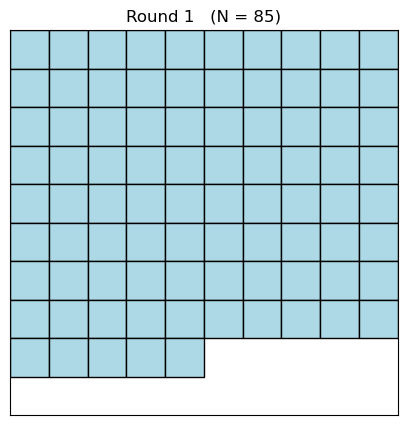

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import clear_output

# --- persistent state (survives re-running the cell) ---
try:
    dice
    round_num
except NameError:
    N0 = 100
    dice = np.ones(N0, dtype=int)   # only the length matters
    round_num = 0

# --- one step (one round) ---
if len(dice) == 0:
    clear_output(wait=True)
    print("All dice have decayed.")
    print("To restart: run the next cell that resets the simulation (or restart kernel).")
else:
    round_num += 1

    # roll dice for those still present
    rolls = np.random.randint(1, 7, size=len(dice))

    # remove 1s (decay)
    dice = dice[rolls != 1]
    N = len(dice)

    # show only one output at a time
    clear_output(wait=True)
    print(f"Round {round_num}: Remaining dice = {N}")
    
    # visualization (remaining squares)
    grid_size = 10
    fig, ax = plt.subplots(figsize=(5,5))
    for i in range(N):
        row = i // grid_size
        col = i % grid_size
        rect = Rectangle((col, grid_size-row-1), 1, 1,
                         facecolor="lightblue", edgecolor="black")
        ax.add_patch(rect)

    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Round {round_num}   (N = {N})")
    plt.show()

In [18]:
import numpy as np
dice = np.ones(100, dtype=int)
round_num = 0
print("Reset complete. Now re-run the step cell to start.")

Reset complete. Now re-run the step cell to start.


---

### **Part C — Monte Carlo Radiocarbon Dating (Simulation + Uncertainty)**

In this part you will simulate how radiocarbon dating measurements are affected by the **random nature of radioactive decay and counting statistics**.

In a real radiocarbon experiment we typically measure the sample **only once**, obtaining a single value for the number of detected ${}^{14}\mathrm{C}$ decay events. However, because radioactive decay is a **stochastic process**, repeating the same measurement many times would not give exactly the same result each time.

Monte Carlo simulation allows us to explore an important question:

> **If we repeated the same radiocarbon measurement many times, how much would the estimated age vary purely due to statistical fluctuations?**

Understanding this uncertainty is essential in real radiocarbon dating. Archaeologists and geologists do not report a single age value, but rather something like

$$
t = 12{,}000 \pm 800 \ \text{years}.
$$

The uncertainty arises largely from the **counting statistics of radioactive decay** and the **background counts in the detector**. By simulating many measurements, we can estimate how large that uncertainty should be.

---

#### **C1. Measurement model**

Suppose we measure the number of ${}^{14}\mathrm{C}$ decays from a sample during a fixed measurement time.

Let

- $S$ = expected **signal counts** from ${}^{14}\mathrm{C}$ in the sample  
- $B$ = expected **background counts** (instrument noise, cosmic radiation, contamination)

The detector measures the total number of counts:

$$
C_{\text{obs}} \sim \text{Poisson}(S + B)
$$

because radioactive decay and counting are random processes that follow **Poisson statistics**.

---

#### **C2. Expected signal from a sample**

A modern (living) reference sample produces an expected signal $S_0$ during the same measurement time.

For a sample with age $t$, the expected number of signal counts is

$$
S(t) = S_0 e^{-\lambda t}
$$

where the decay constant for ${}^{14}\mathrm{C}$ is

$$
\lambda = \frac{\ln 2}{5730 \ \text{yr}}
$$

since the half-life of ${}^{14}\mathrm{C}$ is about 5730 years.

Thus, older samples produce **fewer counts** because much of the ${}^{14}\mathrm{C}$ has already decayed.

---

#### **C3. Estimating age from a measurement**

From the measured counts we estimate the signal

$$
\hat S = C_{\text{obs}} - B
$$

Using the radioactive decay law, the estimated age is

$$
\hat t = \frac{1}{\lambda}\ln\left(\frac{S_0}{\hat S}\right)
$$

Because the observed counts fluctuate randomly, the estimated age $\hat t$ will also vary.

**Important:**  
If $\hat S \le 0$, the signal is indistinguishable from background. In that case the measurement cannot determine an age — the sample is effectively **too old to date with that setup**.

---

#### **C4. Monte Carlo simulation**

To study the statistical uncertainty, we simulate many identical measurements.

1. Choose a **true age** $t_{\text{true}}$.

2. Compute the expected signal

$$
S(t_{\text{true}})
$$

3. Simulate many measurements (for example 10,000 trials):

- draw $C_{\text{obs}}$ from a Poisson distribution  
- compute the estimated age $\hat t$

4. Plot the distribution of estimated ages.

---

#### **C5. What the simulation tells us**

From the simulated measurements you will determine

- the **mean or median estimated age**
- the **standard deviation** (measurement uncertainty)
- the **fraction of invalid measurements** where $\hat S \le 0$

The spread of the simulated ages represents the **statistical uncertainty caused by counting statistics**.

This is exactly how experimental scientists estimate measurement uncertainties.

---

#### **C6. What affects dating accuracy**

Finally, explore how different experimental conditions affect the reliability of radiocarbon dating.

In the code below, three separate parameter studies are performed.

##### 1. Modern carbon contamination

Even a very small amount of modern carbon mixed into an ancient sample can significantly bias the estimated age.

If a fraction $f$ of modern carbon contaminates the sample, the effective signal becomes

$$
S_{\text{eff}} = (1-f)S_0 e^{-\lambda t} + fS_0
$$

Because modern carbon contains much more ${}^{14}\mathrm{C}$ than an ancient sample, even tiny contamination levels can make an old sample appear much younger.

---

##### 2. Background radiation

Real detectors also record background counts from sources such as cosmic rays and natural radioactivity.

A larger background level $B$ increases the statistical noise in the measurement and makes it harder to distinguish very old samples from background radiation.

---

##### 3. Measurement time or sample size

Increasing the measurement time or the amount of material being measured increases the expected signal $S_0$.

More detected counts reduce statistical uncertainty and improve the accuracy of the age estimate.

---

#### **C7. Reliability study (run several true ages)**

To understand when radiocarbon dating becomes unreliable, repeat the Monte Carlo simulation for several different true ages.

Keep $S_0$, $B$, and $f$ the same and run the simulation for the following five cases:

1. $t_{\text{true}} = 500$ years  
2. $t_{\text{true}} = 5{,}000$ years  
3. $t_{\text{true}} = 15{,}000$ years  
4. $t_{\text{true}} = 30{,}000$ years  
5. $t_{\text{true}} = 45{,}000$ years  

For **each case**, record:

- the median estimated age
- the standard deviation (uncertainty)
- the fraction of invalid trials ($\hat S \le 0$)
- a histogram of the estimated ages

---

#### **C8. Final analysis**

After completing all five runs, answer the following questions:

1. For which ages does radiocarbon dating appear **reliable** (small uncertainty and high valid fraction)?
2. At what age does the **uncertainty become large** compared to the estimated age?
3. At what age does the **fraction of invalid measurements** begin to increase significantly?
4. Based on your results, what is the **approximate maximum age that can be reliably dated** using this measurement setup?

---

The Python simulation code for this part appears in the **next code cell below**.

True age t_true = 50,000 years
Expected signal S_true ≈ 11.81 counts (in measurement window)
Valid fraction (S_hat > 0): 88.2%
Median estimated age: 49,205 years
Mean estimated age:   50,549 years
Std dev (uncertainty): 6,242 years


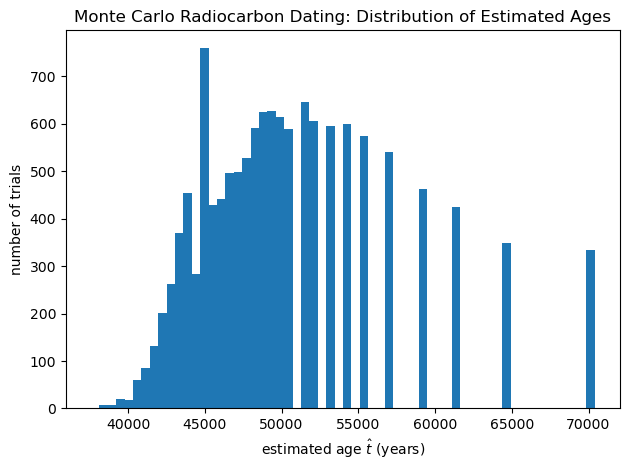


Contamination study (median estimated age):
f = 0.000% | S_true ≈   11.81 | valid  88.0% | median t_hat ≈ 49,205 yr
f = 0.100% | S_true ≈   16.80 | valid  95.1% | median t_hat ≈ 46,987 yr
f = 0.500% | S_true ≈   36.75 | valid 100.0% | median t_hat ≈ 40,558 yr
f = 1.000% | S_true ≈   61.69 | valid 100.0% | median t_hat ≈ 36,291 yr

Background study (median estimated age):
B =   20 counts | valid  98.2% | median t_hat ≈ 49,867 yr
B =   80 counts | valid  88.5% | median t_hat ≈ 49,205 yr
B =  200 counts | valid  78.5% | median t_hat ≈ 47,489 yr
B =  500 counts | valid  69.5% | median t_hat ≈ 45,241 yr

Measurement strength study (median estimated age):
S0 =   1000 counts | valid  57.3% | std ≈ 6,960 yr | median t_hat ≈ 41,018 yr
S0 =   5000 counts | valid  87.9% | std ≈ 6,301 yr | median t_hat ≈ 49,205 yr
S0 =  20000 counts | valid 100.0% | std ≈ 2,154 yr | median t_hat ≈ 50,041 yr


In [26]:
# Part C — Monte Carlo Radiocarbon Dating (Simulation + Uncertainty)
# -----------------------------------------------------------------
# This code simulates a radiocarbon (C-14) measurement with Poisson counting statistics,
# background counts, and optional modern-carbon contamination.
#
# What it does:
#  1) Choose a true age t_true
#  2) Compute expected signal S(t_true) = S0 * exp(-lambda t_true) (with optional contamination)
#  3) Simulate many measurements: C_obs ~ Poisson(S + B)
#  4) Estimate age each time: t_hat = (1/lambda)*ln(S0 / (C_obs - B))
#  5) Plot distribution of estimated ages + report uncertainty + invalid fraction
#  6) (Optional) Parameter studies: contamination, background, and "measurement time" (S0)

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Constants for C-14
# ----------------------------
t_half_14 = 5730.0  # years
lam14 = np.log(2) / t_half_14

# ----------------------------
# Monte Carlo simulator
# ----------------------------
def simulate_carbon_dating(
    t_true_years,
    S0=5000.0,          # expected C-14 signal counts for a modern (living) sample in this measurement window
    B=80.0,             # expected background counts in same measurement window
    f_modern=0.0,       # fraction of modern carbon contamination (0 to 1)
    trials=10000,
    seed=0
):
    rng = np.random.default_rng(seed)

    # Expected signal for the sample, including modern contamination
    # S_eff = (1-f) S0 e^{-lambda t} + f S0
    S_true = (1 - f_modern) * S0 * np.exp(-lam14 * t_true_years) + f_modern * S0

    # Observed counts (signal + background) with Poisson fluctuations
    C_obs = rng.poisson(S_true + B, size=trials)

    # Estimate signal and age
    S_hat = C_obs - B
    valid = S_hat > 0

    t_hat = np.full(trials, np.nan, dtype=float)
    t_hat[valid] = (1 / lam14) * np.log(S0 / S_hat[valid])

    return t_hat, valid.mean(), S_true

# ----------------------------
# Choose a scenario
# ----------------------------
t_true = 50000.0    # years (try 1000, 10000, 40000, 50000)
S0 = 5000.0         # "measurement strength" (bigger means better counting statistics)
B = 80.0            # background counts
f = 0.0             # modern contamination fraction (try 0.001, 0.005, 0.01)

t_hat, frac_valid, S_true = simulate_carbon_dating(
    t_true_years=t_true, S0=S0, B=B, f_modern=f, trials=15000, seed=1
)

t_valid = t_hat[np.isfinite(t_hat)]

print(f"True age t_true = {t_true:,.0f} years")
print(f"Expected signal S_true ≈ {S_true:.2f} counts (in measurement window)")
print(f"Valid fraction (S_hat > 0): {frac_valid*100:.1f}%")
print(f"Median estimated age: {np.median(t_valid):,.0f} years")
print(f"Mean estimated age:   {np.mean(t_valid):,.0f} years")
print(f"Std dev (uncertainty): {np.std(t_valid):,.0f} years")

# Plot distribution of estimated ages
plt.figure()
plt.hist(t_valid, bins=60)
plt.xlabel("estimated age $\\hat t$ (years)")
plt.ylabel("number of trials")
plt.title("Monte Carlo Radiocarbon Dating: Distribution of Estimated Ages")
plt.tight_layout()
plt.show()

# ----------------------------
# Parameter study 1: contamination sensitivity
# ----------------------------
f_list = [0.0, 0.001, 0.005, 0.01]
print("\nContamination study (median estimated age):")
for f_test in f_list:
    t_hat2, frac_valid2, S_true2 = simulate_carbon_dating(
        t_true_years=t_true, S0=S0, B=B, f_modern=f_test, trials=12000, seed=2
    )
    t_valid2 = t_hat2[np.isfinite(t_hat2)]
    print(f"f = {f_test:0.3%} | S_true ≈ {S_true2:7.2f} | valid {frac_valid2*100:5.1f}% | median t_hat ≈ {np.median(t_valid2):,.0f} yr")

# ----------------------------
# Parameter study 2: background sensitivity
# ----------------------------
B_list = [20, 80, 200, 500]
print("\nBackground study (median estimated age):")
for B_test in B_list:
    t_hat3, frac_valid3, S_true3 = simulate_carbon_dating(
        t_true_years=t_true, S0=S0, B=B_test, f_modern=f, trials=12000, seed=3
    )
    t_valid3 = t_hat3[np.isfinite(t_hat3)]
    print(f"B = {B_test:4.0f} counts | valid {frac_valid3*100:5.1f}% | median t_hat ≈ {np.median(t_valid3):,.0f} yr")

# ----------------------------
# Parameter study 3: measurement time / sample size (modeled by S0)
# ----------------------------
S0_list = [1000, 5000, 20000]
print("\nMeasurement strength study (median estimated age):")
for S0_test in S0_list:
    t_hat4, frac_valid4, S_true4 = simulate_carbon_dating(
        t_true_years=t_true, S0=S0_test, B=B, f_modern=f, trials=12000, seed=4
    )
    t_valid4 = t_hat4[np.isfinite(t_hat4)]
    print(f"S0 = {S0_test:6.0f} counts | valid {frac_valid4*100:5.1f}% | std ≈ {np.std(t_valid4):,.0f} yr | median t_hat ≈ {np.median(t_valid4):,.0f} yr")
    

---

## **What to Turn In**

1. **Part A:**  
   - Plot of $C(t)$ vs $t$  
   - Your estimate of the background $B$ (state which bins were used)  
   - Your fitted half-life $t_{1/2}$  
   - A brief sentence explaining which fitting method you used and why.

2. **Part B:**  
   - A table of round number $r$ versus remaining dice $N$  
   - A plot of $N(r)$  
   - Your measured half-life in rounds $r_{1/2}$  
   - A comparison between your measured value and the predicted value using $p = 1/6$.

3. **Part C:**  
   - Results for the five required true ages ($500$, $5{,}000$, $15{,}000$, $30{,}000$, $45{,}000$ years)  
   - At least one histogram showing the distribution of estimated ages $\hat t$  
   - The reported uncertainty (standard deviation of $\hat t$)  
   - The fraction of invalid trials where $\hat S \le 0$  
   - A short discussion describing when radiocarbon dating appears reliable and when it begins to break down.

---

## **Post-Lab Questions**

1. Why does a constant decay probability lead to an exponential decay law?

2. In Part A, why is it necessary to subtract the background $B$ before taking $\ln(C-B)$?

3. In Part B, different groups may measure slightly different half-lives even though the decay probability $p$ is the same. Why does this occur?

4. In Part C, why does radiocarbon dating become unreliable for very old samples?

5. Which factor has the strongest effect on dating very old samples: a larger background $B$ or a small contamination fraction $f$ of modern carbon? Explain your reasoning.

---